## Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

## Download Stock Data

In [2]:
stock_data = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
2020-01-02  72.333893  72.394101  71.091199  71.344069  135480400
2020-01-03  71.630653  72.389273  71.406681  71.563221  146322800
2020-01-06  72.201416  72.239950  70.503554  70.754021  118387200
2020-01-07  71.861847  72.466330  71.642689  72.211049  108872000
2020-01-08  73.017815  73.318854  71.565599  71.565599  132079200


## Understand the Dataset

In [6]:
print("The shape of data is ", stock_data.shape)
print("Columns in the dataset:")
print(stock_data.columns)
print("Dataset info:")
stock_data.info()

The shape of data is  (1258, 5)
Columns in the dataset:
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
Dataset info:
<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


## Select Input Features

In [7]:
X = stock_data[['Open', 'High', 'Low', 'Volume']]

## Select Target Variable

In [8]:
y = stock_data['Close']

## Split Data into Training and Testing

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Splits data:

80% for training
20% for testing

## Create the Linear Regression Model

In [10]:
model = LinearRegression()

## Train the Mode

In [11]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predict Closing Prices

In [12]:
predictions = model.predict(X_test)

I am Checking  Model Accuracy

In [13]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.7418783152970226


## Plot Actual vs Predicted Prices

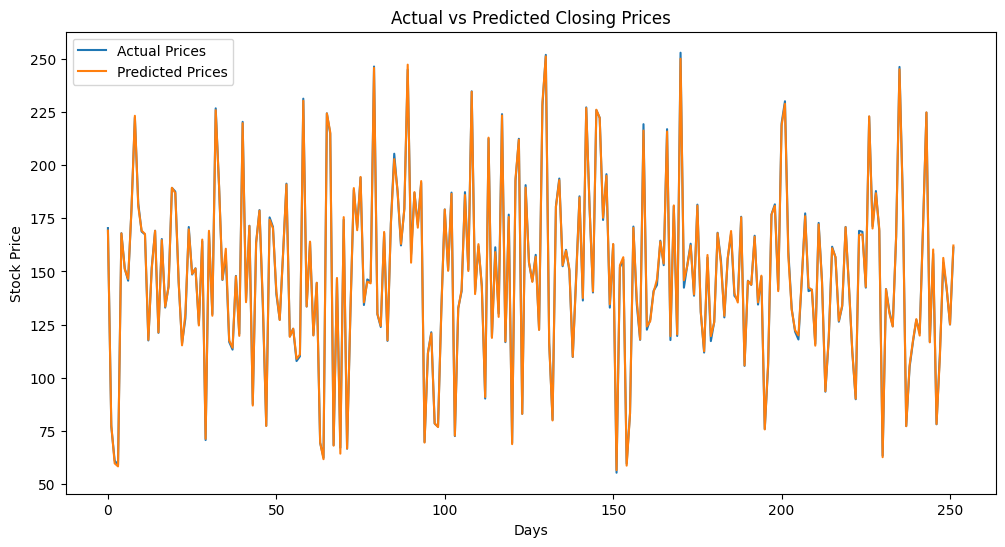

In [14]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Prices')

plt.plot(predictions, label='Predicted Prices')

plt.title('Actual vs Predicted Closing Prices')

plt.xlabel('Days')

plt.ylabel('Stock Price')

plt.legend()

plt.show()